In [38]:
import tqdm

In [39]:
from model import DevanagariNetwork

In [40]:
import os
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense,Conv2D,MaxPooling2D,Flatten,BatchNormalization,Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [41]:
# Example mapping dictionary
mapping = {
    "consonants": {
        "1": "ka", "2": "kha", "3": "ga","4": "gha","5": "kna","6": "cha","7": "chha","8": "ja","9": "jha","10": "yna",
        "11": "ta","12": "tha","13": "da","14": "dha","15": "ana","16": "taa","17": "thaa","18": "daa","19": "dhaa","20": "na",
        "21": "pa", "22": "pha", "23": "ba","24":"bha","25": "ma","26": "ya","27": "ra","28": "la","29": "va","30": "motosaw",
        "31": "petchiryosaw", "32": "patalosaw", "33": "ha","34": "ksha","35": "tra","36": "gya"

        # Add all consonant mappings
    },
    "vowels": {
        "1": "a", "2": "aa", "3": "i","4": "ee","5": "u","6": "oo","7": "ae","8": "ai","9": "o","10": "au",
        "11": "an", "12": "ah" # Add all vowel mappings
    },
    "numerals": {
        "0": "0","1": "1", "2": "2", "3": "3","4": "4","5": "5","6": "6","7": "7","8": "8","9": "9"  # Add all numeral mappings
    }
}

import os
import shutil

# Define source and destination directories
source_dir = r"G:\AI_interns\task_4\archive (6)\nhcd\nhcd"
destination_dir = r"datasets"

# Create destination directory if it doesn't exist
os.makedirs(destination_dir, exist_ok=True)

# Iterate only over categories present in the mapping
for category in mapping.keys():  # Change here
    category_path = os.path.join(source_dir, category)

    if os.path.isdir(category_path):
        # Iterate over subfolders (1, 2, 3, ...)
        for label in os.listdir(category_path):
            label_path = os.path.join(category_path, label)

            if os.path.isdir(label_path):
                # Map the numeric label to the corresponding Devanagari character
                devanagari_label = mapping[category].get(label)

                if devanagari_label:
                    # Create the corresponding folder in the destination directory
                    mapped_folder = os.path.join(destination_dir, category, devanagari_label)
                    os.makedirs(mapped_folder, exist_ok=True)

                    # Copy images to the new folder
                    for image_file in os.listdir(label_path):
                        source_file = os.path.join(label_path, image_file)
                        destination_file = os.path.join(mapped_folder, image_file)
                        shutil.copy(source_file, destination_file)
                else:
                    print(f"Warning: No mapping found for label '{label}' in category '{category}'")

In [42]:
source_dir = r'G:\AI_interns\new_task_4\datasets'
dest_dir = r'combine_dataset'
if not os.path.exists(dest_dir):
    os.makedirs(dest_dir)
for root, dirs, files in os.walk(source_dir):
    # Check if the current directory has subsubfolders
    if any(os.path.isdir(os.path.join(root, d)) for d in dirs):
        # Determine if this is a directory with subsubfolders
        for dir_name in dirs:
            subfolder_path = os.path.join(root, dir_name)
            for subsub_name in os.listdir(subfolder_path):
                subsub_path = os.path.join(subfolder_path, subsub_name)
                if os.path.isdir(subsub_path):
                    # Copy the subsubfolder to the destination directory
                    dest_subsub_path = os.path.join(dest_dir, subsub_name)
                    shutil.copytree(subsub_path, dest_subsub_path, dirs_exist_ok=True)





{'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5, '6': 6, '7': 7, '8': 8, '9': 9, 'a': 10, 'aa': 11, 'ae': 12, 'ah': 13, 'ai': 14, 'an': 15, 'ana': 16, 'au': 17, 'ba': 18, 'bha': 19, 'cha': 20, 'chha': 21, 'da': 22, 'daa': 23, 'dha': 24, 'dhaa': 25, 'ee': 26, 'ga': 27, 'gha': 28, 'gya': 29, 'ha': 30, 'i': 31, 'ja': 32, 'jha': 33, 'ka': 34, 'kha': 35, 'kna': 36, 'ksha': 37, 'la': 38, 'ma': 39, 'motosaw': 40, 'na': 41, 'o': 42, 'oo': 43, 'pa': 44, 'patalosaw': 45, 'petchiryosaw': 46, 'pha': 47, 'ra': 48, 'ta': 49, 'taa': 50, 'tha': 51, 'thaa': 52, 'tra': 53, 'u': 54, 'va': 55, 'ya': 56, 'yna': 57}
{0: '0', 1: '1', 2: '2', 3: '3', 4: '4', 5: '5', 6: '6', 7: '7', 8: '8', 9: '9', 10: 'a', 11: 'aa', 12: 'ae', 13: 'ah', 14: 'ai', 15: 'an', 16: 'ana', 17: 'au', 18: 'ba', 19: 'bha', 20: 'cha', 21: 'chha', 22: 'da', 23: 'daa', 24: 'dha', 25: 'dhaa', 26: 'ee', 27: 'ga', 28: 'gha', 29: 'gya', 30: 'ha', 31: 'i', 32: 'ja', 33: 'jha', 34: 'ka', 35: 'kha', 36: 'kna', 37: 'ksha', 38: 'la', 39: 'ma', 40:

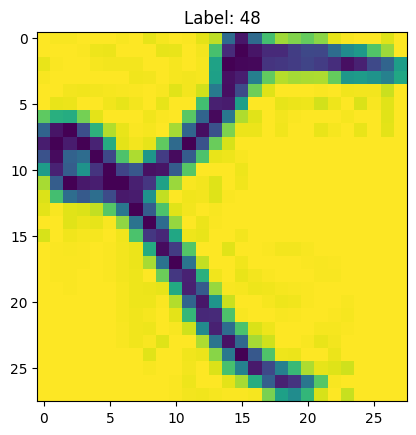

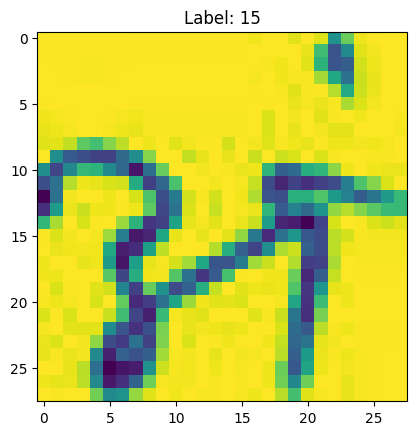

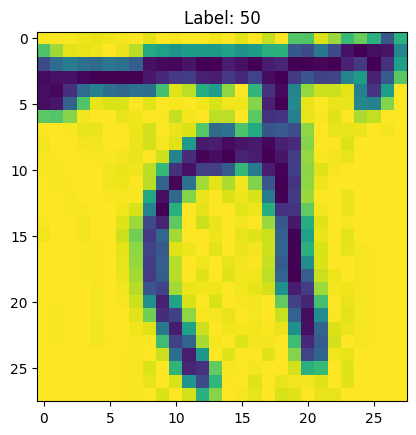

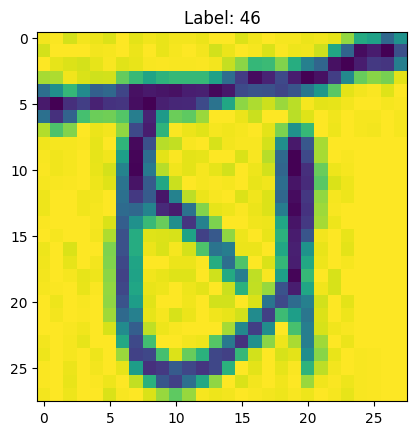

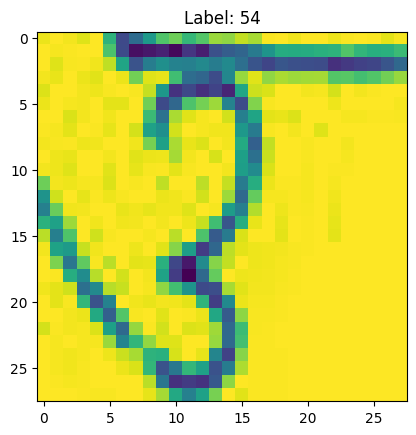

In [43]:
import torch
from torch.utils.data import random_split, DataLoader
from torchvision import datasets, transforms

# # Define the data transformation (if needed)
# transform = transforms.Compose([
#     transforms.Resize((28, 28)),
#     transforms.Grayscale(),
#     transforms.RandomHorizontalFlip(p=0.5),  # Randomly flip the image horizontally
#     transforms.RandomRotation(10),           # Randomly rotate the image by up to 10 degrees
#     transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),  # Random affine transformation
#     transforms.RandomResizedCrop(28, scale=(0.8, 1.0)),  # Randomly crop and resize the image
#     transforms.ToTensor(),
#     transforms.Normalize((0.5,), (0.5,))
#     # Add more transformations if necessary
# ])
train_transform = transforms.Compose([
        transforms.Resize((28, 28)),
        transforms.RandomResizedCrop((28, 28), scale=(0.8, 1.0)),
        transforms.RandomRotation(10),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1),scale=(0.9, 1.1)),
        transforms.RandomApply([transforms.GaussianBlur(kernel_size=3)], p=0.3),
        transforms.ToTensor(),
        transforms.Grayscale(),  # Move Grayscale to be applied before normalization
        transforms.Normalize([0.5], [0.5]), # Normalization should be applied after converting to Grayscale
    ])


# Apply basic preprocessing to the test data
test_transform = transforms.Compose([
        transforms.Resize((28, 28)),
        transforms.Grayscale(),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5])
])
# Load the dataset using ImageFolder
dataset = datasets.ImageFolder(root="combine_dataset", transform=train_transform)
class_to_idx=dataset.class_to_idx
print(class_to_idx)

idx_to_class={v:k for k,v in class_to_idx.items()}
print(idx_to_class)

# Define the split ratio
train_size = int(0.8 * len(dataset))
val_size=int(0.15*len(dataset))
test_size = len(dataset) - train_size-val_size

# Randomly split the dataset into training and testing sets
train_dataset,val_dataset, test_dataset = random_split(dataset, [train_size, val_size, test_size])
val_dataset.dataset.transform = test_transform
test_dataset.dataset.transform = test_transform

# Create data loaders for training and testing sets
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Check if augmentation is applied
from PIL import Image
import matplotlib.pyplot as plt
# Visualize a few augmented images
for i, (img, label) in enumerate(train_loader):
    if i == 5:  # View first 5 images
        break
    img = img[0].permute(1, 2, 0).numpy()  # Convert to numpy for visualization
    plt.imshow(img)
    plt.title(f'Label: {label[0]}')
    plt.show()


In [44]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

In [45]:
# import torch.nn as nn
# import torch.nn.functional as F
# class DevanagariCNN(nn.Module):
#     def __init__(self):
#         super(DevanagariCNN, self).__init__()
#         self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
#         self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
#         self.pool = nn.MaxPool2d(2, 2)
#         self.dropout = nn.Dropout(0.25)
#         # Calculate the correct flattened size here
#         self.fc1 = nn.Linear(64 * 14 * 14, 128)
#         self.fc2 = nn.Linear(128, 46)  # Assuming 46 classes for Devanagari characters

#     def forward(self, x):
#         x = self.pool(F.relu(self.conv1(x)))
#         x = self.pool(F.relu(self.conv2(x)))
#         x=self.dropout(x)
#         x=x.view(x.size(0),-1)
#         x = F.relu(self.fc1(x))
#         x = self.fc2(x)  # Output logits, no need for Softmax here
#         return x

In [46]:
import torch.nn as nn
import torch.nn.functional as F

class DevanagariNetwork(nn.Module):
    def __init__(self):
        super(DevanagariNetwork,self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 5,padding=2)  # Conv2d: 1 input channel, 6 output channels, 5x5 kernel
        self.pool = nn.MaxPool2d(2, 2)  # MaxPooling with 2x2 kernel
        self.conv2 = nn.Conv2d(32, 64, 5,padding=2)
        self.conv3=nn.Conv2d(64,128,5,padding=2)  # Conv2d: 6 input channels, 16 output channels, 5x5 kernel
        self.dropout=nn.Dropout(0.25)
        # Calculate the flattened dimension after conv and pooling layers
        self.fc1 = nn.Linear(128*3*3, 256)  # Adjusted flattened size
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 58)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))  # After conv1 + pool, the size becomes 24x24
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))
        x = torch.flatten(x, 1)  
        x = F.relu(self.fc1(x))
        x= self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


In [47]:


device = ("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using {device} device")
model = DevanagariNetwork().to(device)
print(model)

Using cpu device
DevanagariNetwork(
  (conv1): Conv2d(1, 32, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(32, 64, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (conv3): Conv2d(64, 128, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
  (dropout): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=1152, out_features=256, bias=True)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=58, bias=True)
)


In [48]:
# import torch
# import tqdm

# def train_network(model, train_loader, test_loader, optimizer, criterion, epochs, device, val_interval):
#     train_loss_value = []
#     val_loss_value = []
#     val_accuracy_value = []
#     for epoch in range(epochs):
#         print('-' * 10)
#         print(f"epochs {epoch+1}/{epochs}")
#         model.train()
#         epoch_loss = 0
#         step = 0
#         for batch_data in tqdm.tqdm(train_loader):
#             step += 1
#             optimizer.zero_grad()
#             inputs, labels = batch_data
#             inputs = inputs.to(device)
#             labels = labels.to(device)
#             outputs = model(inputs)
#             loss = criterion(outputs, labels)
#             loss.backward()
#             optimizer.step()
#             epoch_loss += loss.item()

#         epoch_loss /= step
#         train_loss_value.append(epoch_loss)
#         print(f"Epoch {epoch + 1} average training loss: {epoch_loss:.4f}")

#         if (epoch + 1) % val_interval == 0:
#             model.eval()
#             val_epoch_loss = 0
#             val_step = 0
#             correct_count = 0
#             with torch.no_grad():
#                 for val_data in test_loader:
#                     val_step += 1
#                     val_inputs, val_labels = val_data
#                     val_inputs = val_inputs.to(device)
#                     val_labels = val_labels.to(device)
#                     model_out = model(val_inputs)
#                     val_loss = criterion(model_out, val_labels)
#                     val_epoch_loss += val_loss.item()
#                     correct_count += (model_out.argmax(1) == val_labels).type(torch.float).sum().item()

#             val_epoch_loss /= val_step
#             accuracy = correct_count / len(test_loader.dataset)
#             val_loss_value.append(val_epoch_loss)
#             val_accuracy_value.append(accuracy)
#             print(f"Epoch {epoch + 1} average validation loss: {val_epoch_loss:.4f}")
#             print(f"Validation Accuracy: {(100 * accuracy):>0.1f}% \n")

#     return train_loss_value, val_loss_value, val_accuracy_value


In [49]:
# cell 37
# Your code here

def train(model,train_dataloader, val_dataloader, loss_fn, optimizer, epochs, device, val_interval=1):
    early_stopping = EarlyStopping(patience=3, min_delta=0.001)
    train_loss_values = []
    val_loss_values = []
    train_accuracy_values=[]
    val_accuracy_values = []
    # Training loop
    for epoch in range(epochs):
        print("-" * 10)
        print(f"epoch {epoch + 1}/{epochs}")
        model.train()   # set model on training mode
        epoch_loss = 0
        val_epoch_loss = 0
        step = 0
        epoch_correct_count = 0
        correct_count = 0
        for batch_data in tqdm.tqdm(train_dataloader):
            step += 1
            inputs, labels = (
                batch_data[0].to(device),
                batch_data[1].to(device),
            )
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = loss_fn(outputs, labels)   # Batch loss
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            epoch_correct_count += (outputs.argmax(1) == labels).type(torch.float).sum().item()

        epoch_loss /= step
        train_loss_values.append(epoch_loss)
        train_accuracy = epoch_correct_count / len(train_dataloader.dataset)
        train_accuracy_values.append(train_accuracy)
        print(f"Epoch {epoch + 1} average training loss: {epoch_loss:.4f}")
        print(f"Epoch {epoch + 1} training accuracy: {100 * train_accuracy:.1f}%")

        # Validation loop
        if (epoch + 1) % val_interval == 0:
            model.eval()    # Setting model in eval mode
            with torch.no_grad():
                val_step = 0
                for val_data in val_dataloader:
                    val_step += 1
                    val_inputs, val_labels = (
                      val_data[0].to(device),
                      val_data[1].to(device),
                    )
                    outputs = model(val_inputs)
                    loss = loss_fn(outputs, val_labels)   # Batch loss
                    val_epoch_loss += loss.item()
                    correct_count += (outputs.argmax(1) == val_labels).type(torch.float).sum().item()
                    # print(correct_count)
            val_epoch_loss /= val_step
            accuracy = correct_count / len(val_dataloader.dataset)
            val_loss_values.append(val_epoch_loss)
            val_accuracy_values.append(accuracy)
            print(f"Epoch {epoch + 1} average validation loss: {val_epoch_loss:.4f}")
            print(f"Validation Accuracy: {(100 * accuracy):>0.1f}% \n")

            early_stopping(val_epoch_loss)
            if early_stopping.early_stop:
              print("Early stopping triggered.")
              break

    return train_loss_values, val_loss_values, train_accuracy_values,val_accuracy_values


In [50]:
import numpy as np
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = np.inf
        self.early_stop = False

    def __call__(self, val_loss):
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True


In [51]:
# def train_network(model,train_loader,test_loader,optimizer,criterion,epochs,device,val_interval):
#   train_loss_value=[]
#   val_loss_value=[]
#   val_accuracy_value=[]
#   for epoch in range(epochs):
#     print('-'*10)
#     print(f"epochs {epoch+1}/{epochs}")
#     model.train()
#     epoch_loss=0
#     val_epoch_loss=0
#     step=0
#     correct_count=0
#     for batch_data in tqdm.tqdm(train_loader):
#       step+=1
#       optimizer.zero_grad()
#       inputs,labels=batch_data
#       inputs=inputs.to(device)
#       labels=labels.to(device)
#       outputs=model(inputs)
#       labels = labels.view(-1)
#       loss=criterion(outputs,labels)
#       loss.backward()
#       optimizer.step()
#       epoch_loss+=loss.item()

#     epoch_loss/=step
#     train_loss_value.append(epoch_loss)
#     print(f"Epoch {epoch + 1} average training loss: {epoch_loss:.4f}")

#     if (epoch + 1) % val_interval == 0:
#         model.eval()
#         val_step = 0
#         val_correct_count = 0
#         with torch.no_grad():
#           for val_data in test_loader:
#             val_step += 1
#             val_inputs, val_labels = val_data
#             val_inputs=val_inputs.to(device)
#             val_labels=val_labels.to(device)
#             model_out=model(val_inputs)
#             loss_fn=criterion(model_out,val_labels)
#             val_epoch_loss+=loss_fn.item()
#             correct_count += (outputs.argmax(1) == val_labels).type(torch.float).sum().item()
#         val_epoch_loss /= val_step
#         accuracy = correct_count / len(test_loader.dataset)
#         val_loss_value.append(val_epoch_loss)
#         val_accuracy_value.append(accuracy)
#         print(f"Epoch {epoch + 1} average validation loss: {val_epoch_loss:.4f}")
#         print(f"Validation Accuracy: {(100 * accuracy):>0.1f}% \n")

#     return train_loss_value, val_loss_value, val_accuracy_value


In [52]:
# cell 38
learning_rate = 1e-3
batch_size = 64
epochs = 20

In [53]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
train_loss_values, val_loss_values,train_accuracy_values, val_accuracy_values = train(model,train_loader, val_loader, loss_fn, optimizer, epochs, device, val_interval=1)

----------
epoch 1/20


100%|██████████| 323/323 [01:05<00:00,  4.96it/s]


Epoch 1 average training loss: 2.3685
Epoch 1 training accuracy: 37.5%
Epoch 1 average validation loss: 0.8560
Validation Accuracy: 74.7% 

----------
epoch 2/20


100%|██████████| 323/323 [00:23<00:00, 13.79it/s]


Epoch 2 average training loss: 0.6726
Epoch 2 training accuracy: 78.6%
Epoch 2 average validation loss: 0.4247
Validation Accuracy: 86.4% 

----------
epoch 3/20


...

Epoch 10 average training loss: 0.0863
Epoch 10 training accuracy: 97.3%
Epoch 10 average validation loss: 0.2902
Validation Accuracy: 93.0% 

----------
epoch 11/20


100%|██████████| 323/323 [00:21<00:00, 14.73it/s]


Epoch 11 average training loss: 0.0747
Epoch 11 training accuracy: 97.8%
Epoch 11 average validation loss: 0.2967
Validation Accuracy: 93.2% 

----------
epoch 12/20


100%|██████████| 323/323 [00:22<00:00, 14.17it/s]


Epoch 12 average training loss: 0.0729
Epoch 12 training accuracy: 97.8%
Epoch 12 average validation loss: 0.3012
Validation Accuracy: 93.2% 

Early stopping triggered.


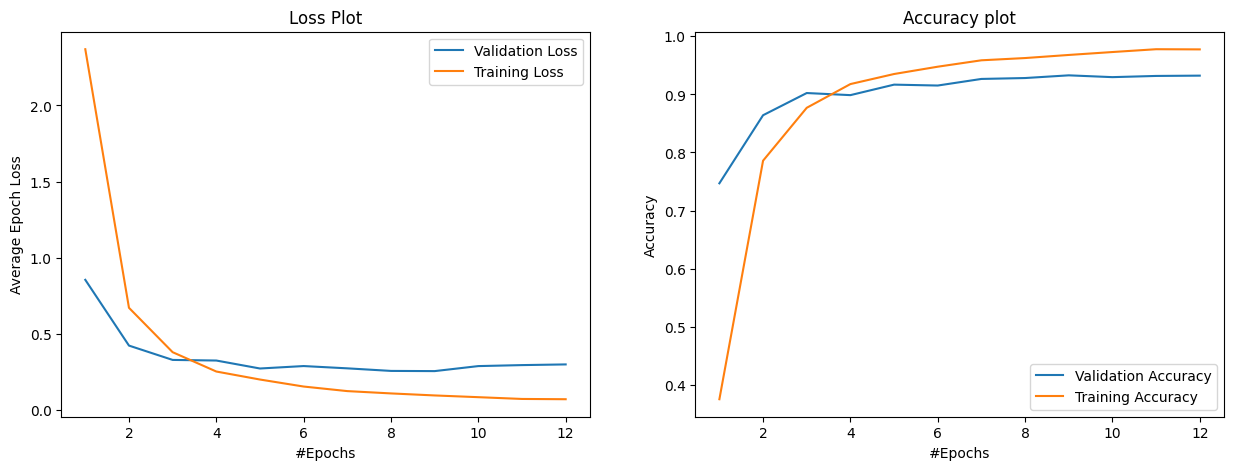

In [54]:
# cell 40
val_interval = 1
plt.figure(figsize=(15, 5))

# Subplot for training and validation loss
plt.subplot(1, 2, 1)
plt.title("Loss Plot")
train_num_epoch = [i + 1 for i in range(len(train_loss_values))]
val_num_epoch = [val_interval * (i + 1) for i in range(len(val_loss_values))]
plt.plot(val_num_epoch, val_loss_values)
plt.plot(train_num_epoch, train_loss_values)
plt.legend(["Validation Loss", "Training Loss"])
plt.xlabel("#Epochs")
plt.ylabel("Average Epoch Loss")

# Subplot for validation accuracy
plt.subplot(1, 2, 2)
train_num_epoch = [i + 1 for i in range(len(train_accuracy_values))]
val_num_epoch = [val_interval * (i + 1) for i in range(len(val_accuracy_values))]
plt.plot(val_num_epoch, val_accuracy_values)
plt.plot(train_num_epoch, train_accuracy_values)
plt.legend(["Validation Accuracy", "Training Accuracy"])
plt.title("Accuracy plot")
plt.xlabel("#Epochs")
plt.ylabel("Accuracy")
plt.show()

In [55]:
transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.Grayscale(),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load and transform the image
image = Image.open(r'G:\AI_interns\new_task_4\test_img\kaa.png').convert('L')
image = transform(image)
image = image.unsqueeze(0)

# Move the image to the GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
image = image.to(device)  # Move image tensor to the same device as the model

# Make predictions
with torch.no_grad():
    output = model(image)

# Get the predicted class
_, predicted = torch.max(output, 1)
predicted_class = predicted.item()
predicted_class_name=idx_to_class[predicted_class]
print(predicted_class)
print(f"Predicted Class: {predicted_class_name}")

14
Predicted Class: ai


In [ ]:
torch.save(model.state_dict(),'model/best_model.pth')

In [ ]:
checkpoint = {
    "model_state": model.state_dict(),
    "optimizer_state": optimizer.state_dict(),
    "train_loss": train_loss_values,
    "val_loss": val_loss_values,
    "val_accuracy": val_accuracy_values
}
torch.save(checkpoint, 'model/checkpoint.pth.tar')

In [58]:
model=DevanagariNetwork()
optimizer=torch.optim.Adam(model.parameters(),lr=learning_rate)
checkpoint=torch.load('checkpoint.pth.tar')
model.load_state_dict(checkpoint['model_state'])
optimizer.load_state_dict(checkpoint['optimizer_state'])
train_loss_values = checkpoint['train_loss']
val_loss_values = checkpoint['val_loss']
val_accuracy_values = checkpoint['val_accuracy']

C:\Users\Dell\AppData\Local\Temp\ipykernel_7600\3432328621.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint=torch.load('checkpoint.pth.tar')


In [59]:
correct_count=0
model.eval()
with torch.no_grad():
  for data,label in test_loader:
    images,labels=data.to(device),label.to(device)
    output=model(images)
    _,pred=torch.max(output,1)
    correct_count += (output.argmax(1) == labels).type(torch.float).sum().item()
accuracy = correct_count / len(test_loader.dataset)
print(accuracy)

0.9273570324574961


In [60]:
from sklearn.metrics import confusion_matrix
model.eval()
all_pred=[]
all_labels=[]
with torch.no_grad():
  for data,label in test_loader:
    images,labels=data.to(device),label.to(device)
    output=model(images)
    _,pred=torch.max(output,1)
    all_pred.extend(pred.cpu().numpy())
    all_labels.extend(labels.cpu().numpy())

conf_matrix=confusion_matrix(all_labels,all_pred)

In [61]:
print(conf_matrix)

[[12  0  0 ...  0  0  0]
 [ 0 13  0 ...  0  0  0]
 [ 0  0 12 ...  0  0  0]
 ...
 [ 0  0  0 ... 10  0  0]
 [ 0  0  0 ...  0  6  0]
 [ 0  0  0 ...  0  0  7]]


<Axes: >

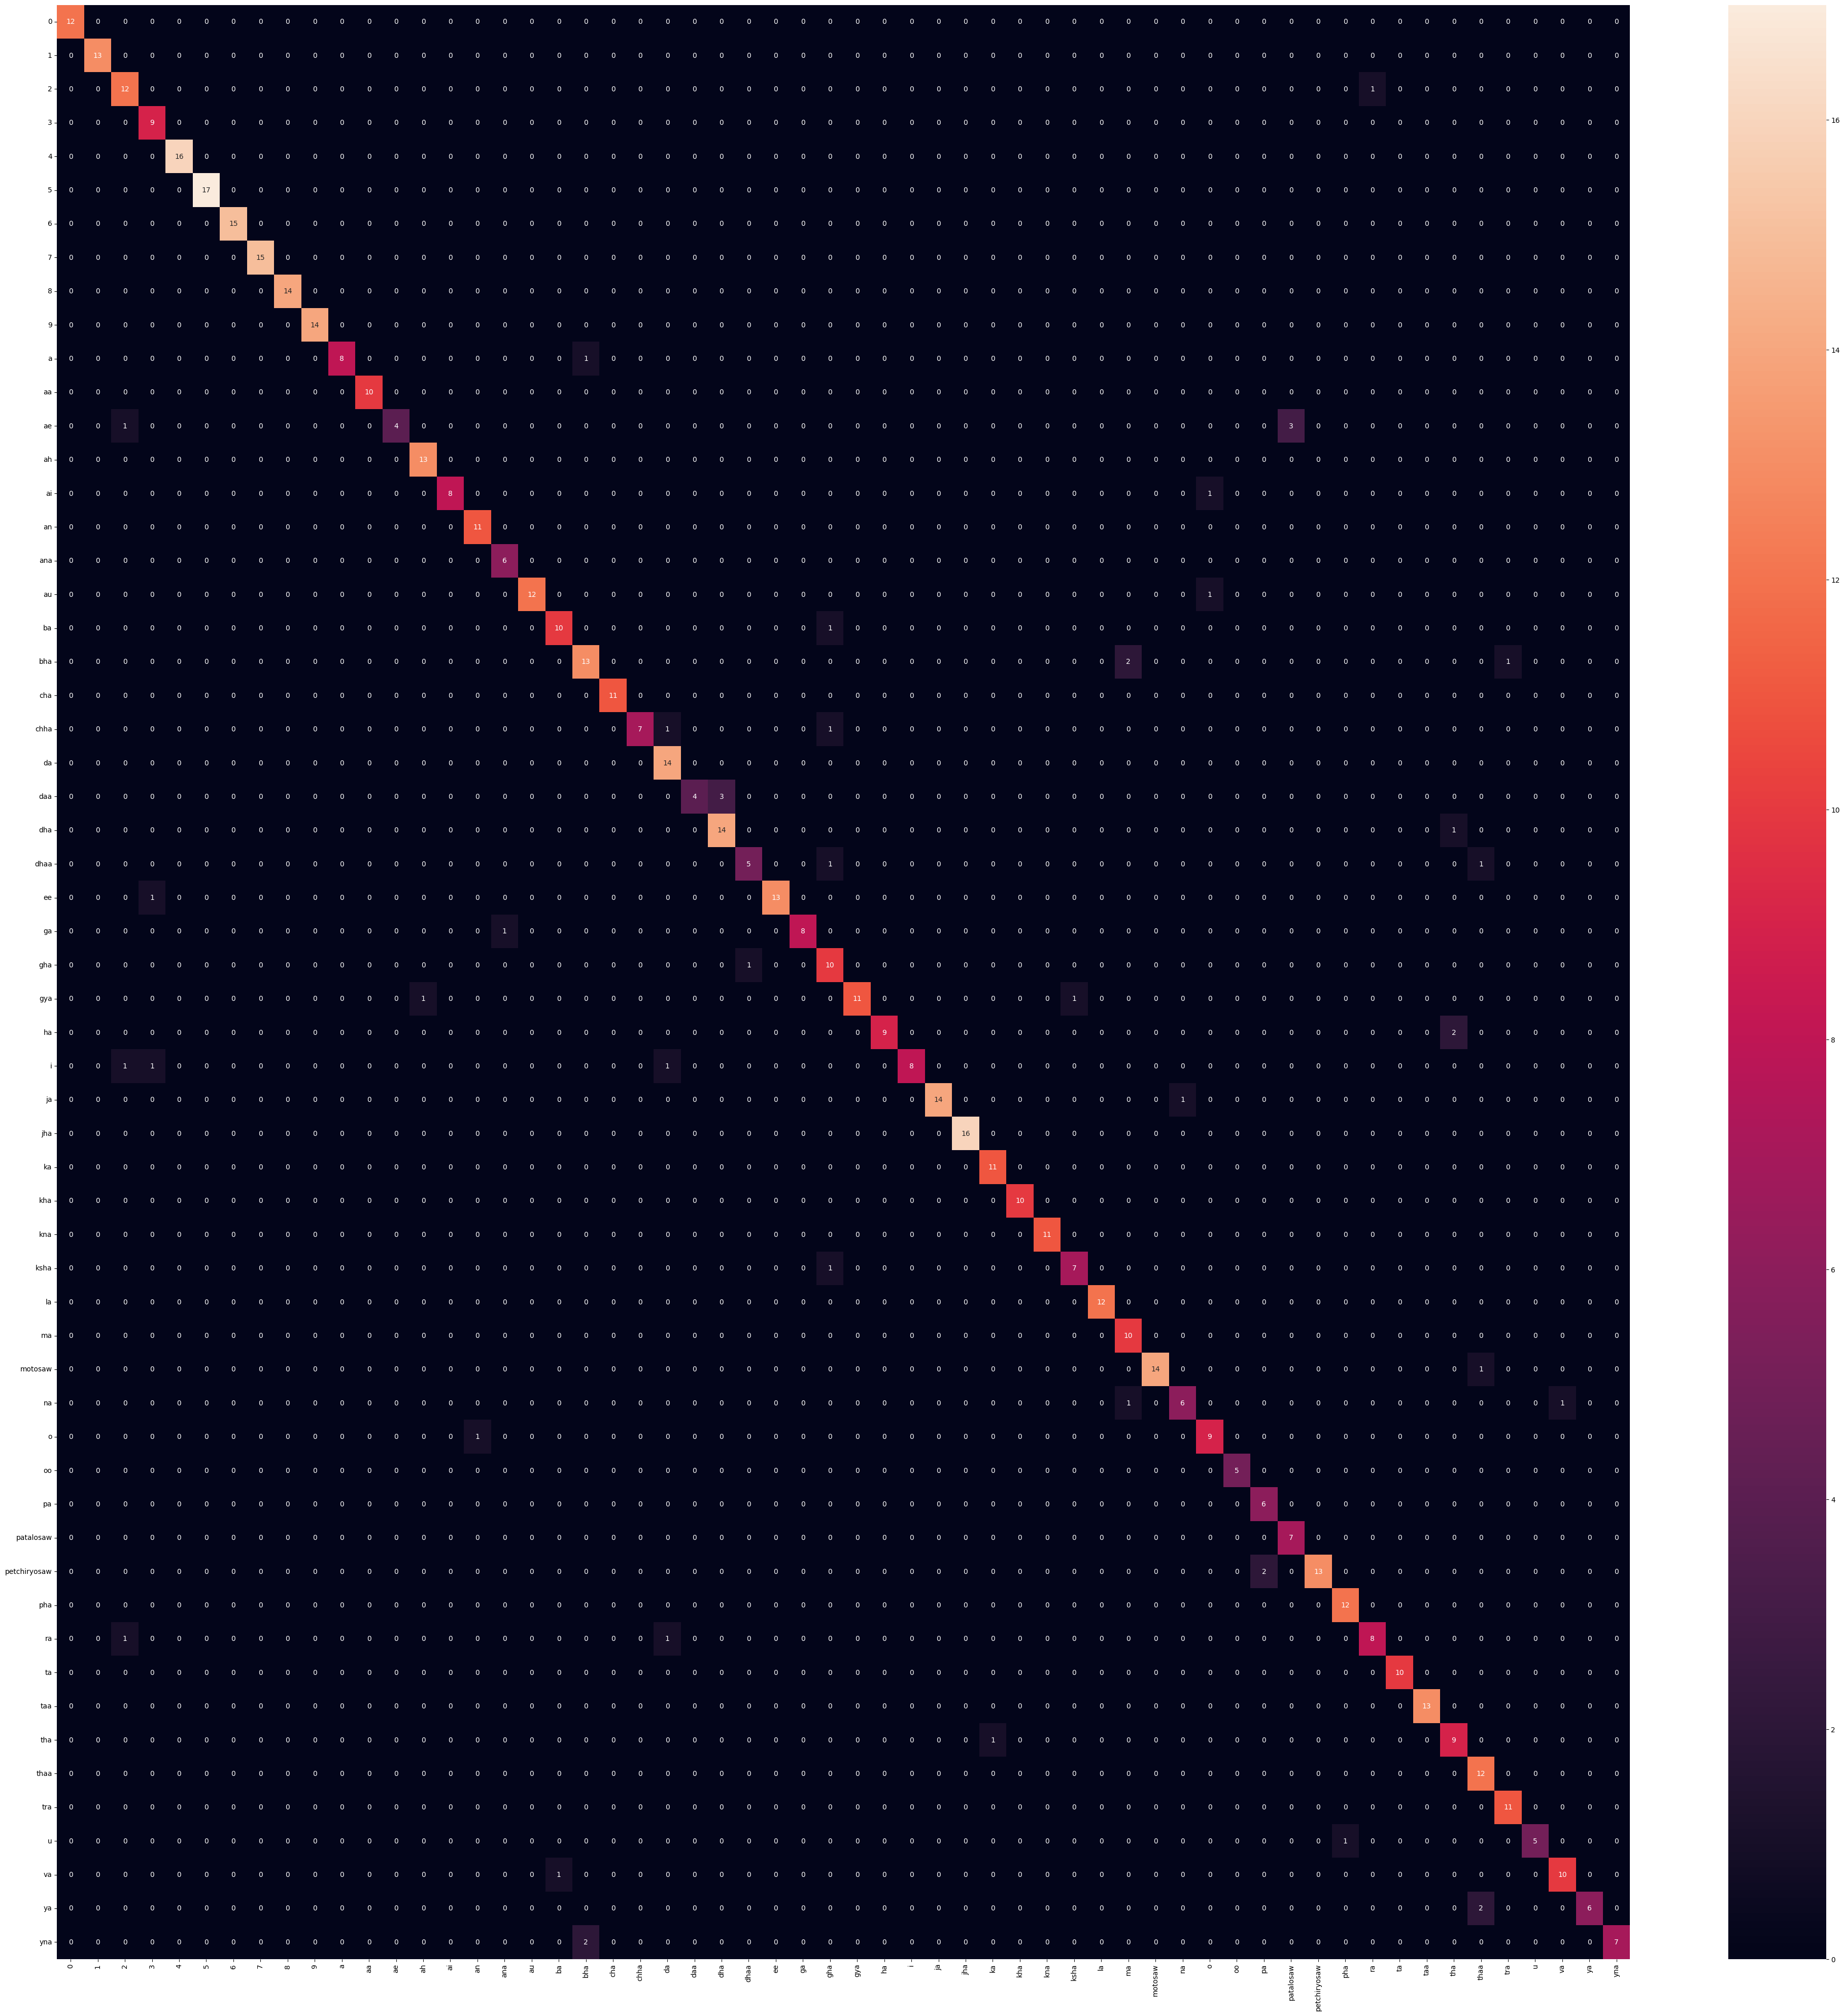

In [62]:
import seaborn as sns
plt.figure(figsize=(50,50))
sns.heatmap(conf_matrix,annot=True,fmt='d',xticklabels=class_to_idx.keys(),yticklabels=class_to_idx.keys())

In [88]:
def predict(img_pth):
  transform = transforms.Compose([
    transforms.Resize((28, 28)),
    transforms.Grayscale(),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
  ])

# Load and transform the image
  image = Image.open(img_pth).convert('L')
  image = transform(image)
  image = image.unsqueeze(0)

# Move the image to the GPU if available
  device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
  image = image.to(device)  # Move image tensor to the same device as the model

  # Make predictions
  with torch.no_grad():
      output = model(image)

# Get the predicted class
  _, predicted = torch.max(output, 1)
  predicted_class = predicted.item()
  predicted_class_name=idx_to_class[predicted_class]
  print(predicted_class)
  print(f"Predicted Class: {predicted_class_name}")

In [89]:
img_path=r'G:\AI_interns\new_task_4\test_img\test2\chaaa.jpeg'
predict(img_path)

15
Predicted Class: an
